# Viscosity Pipeline Usage Example

This notebook shows how to run the reusable viscosity pipeline on:
`dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv`

Workflow covered:
1. Load dataset
2. Normalize x-axis by cell
3. Trim before-hit and after-contact zones
4. Fit Polynomial(2nd) and Hyperbola
5. Map known real viscosities (user input)
6. Extrapolate unknown viscosities
7. Plot fits and accuracy

In [5]:
from pathlib import Path
import sys

import pandas as pd

# Locate helper module robustly across common notebook working directories.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'results' / 'Auto-runs',
    Path.cwd().parent,
]
helper_dir = next((d for d in candidate_dirs if (d / 'viscosity_pipeline_helper.py').exists()), None)
if helper_dir is None:
    raise FileNotFoundError('Could not locate viscosity_pipeline_helper.py')
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

from viscosity_pipeline_helper import run_viscosity_pipeline

In [6]:
# Dataset to analyze
#csv_path = 'full_run_260428.csv'
csv_path = 'dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv'

# USER INPUT: known calibration viscosities in cP.
# Keep only cells you trust for calibration. Unknown cells can be omitted.
real_viscosity_map = {
    1: 37000,
    2: 37000,
    3: 37000,
    4: 37000,
    5: 37000,
    6: 37000,
    7: 37000,
    8: 37000,
    9: 37000,
    10: 37000,
    11: 37000,
    12: 37000,
    13: 37000,
    14: 37000,
    15: 37000,
    16: 37000,
    17: 37000,
    18: 37000
}

# real_viscosity_map = {
#     1: 1000,
#     2: 1154,
#     3: 3347,
#     4: 6611,
#     5: 5865,
#     6: 8930,
#     7: 11860,
#     8: 14590,
#     9: 19000,
#     10: 22730,
#     11: 31870,
#     12: 40850,
#     13: 48520,
#     14: 37020,
#     15: 69080,
#     16: 70730,
#     17: 93270,
#     18: 124800,
# }

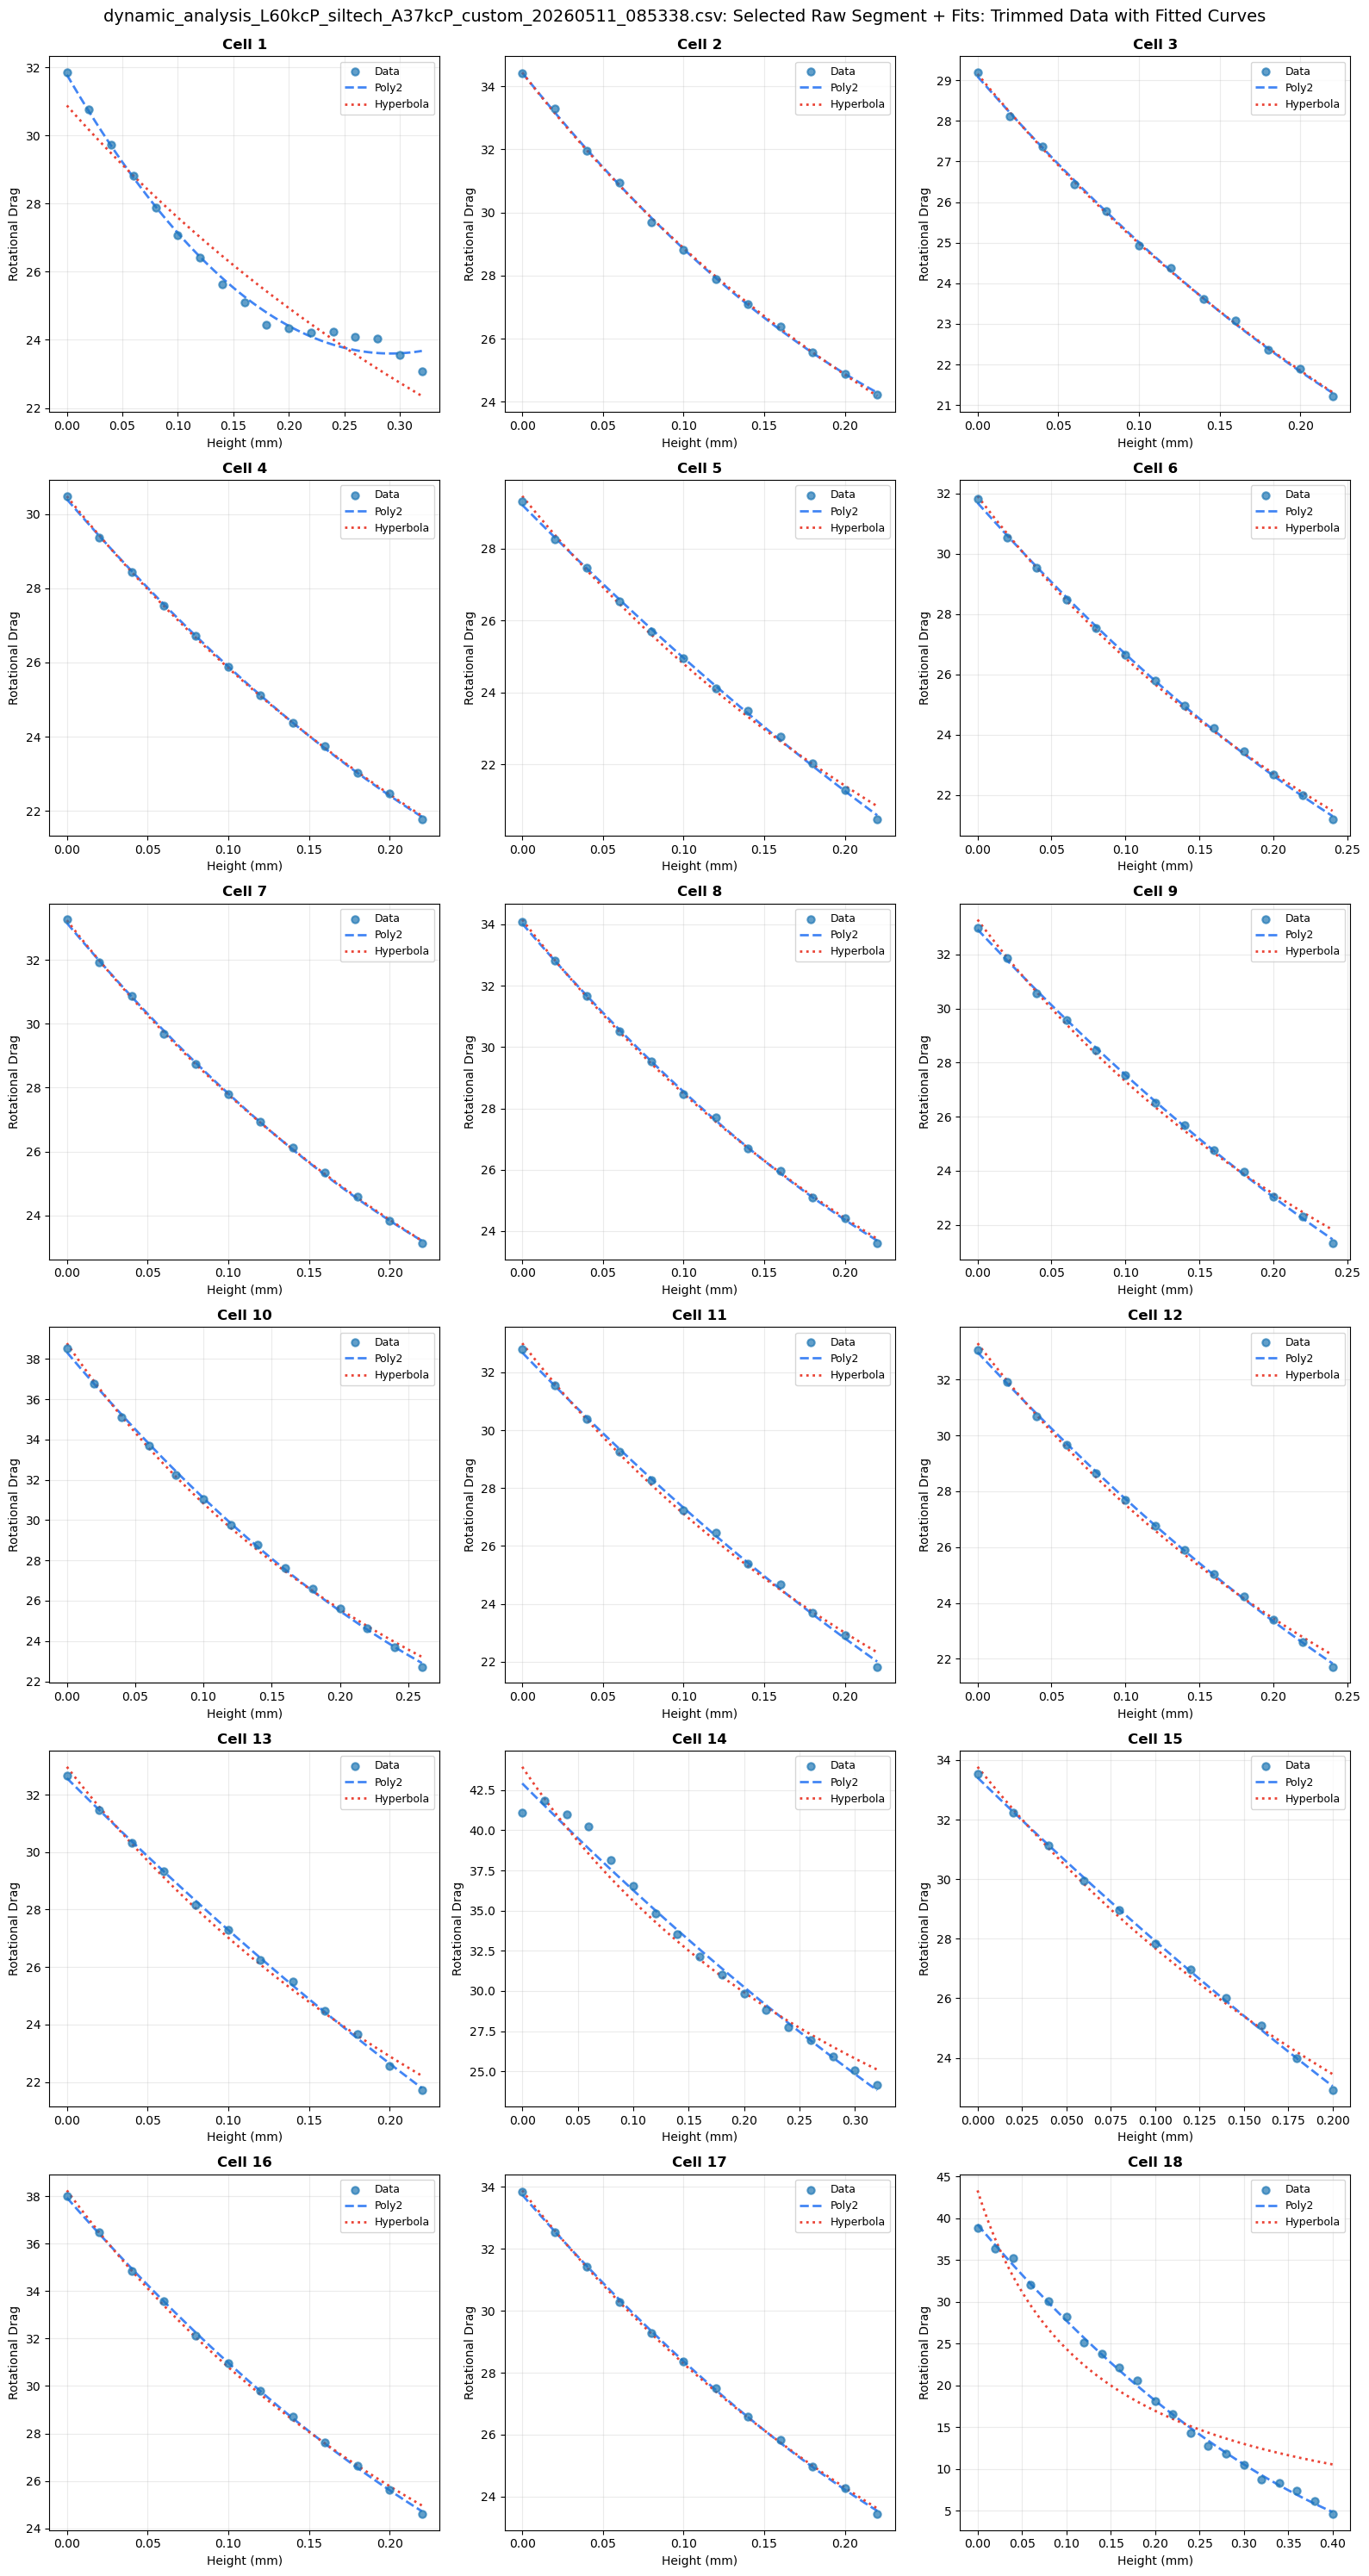

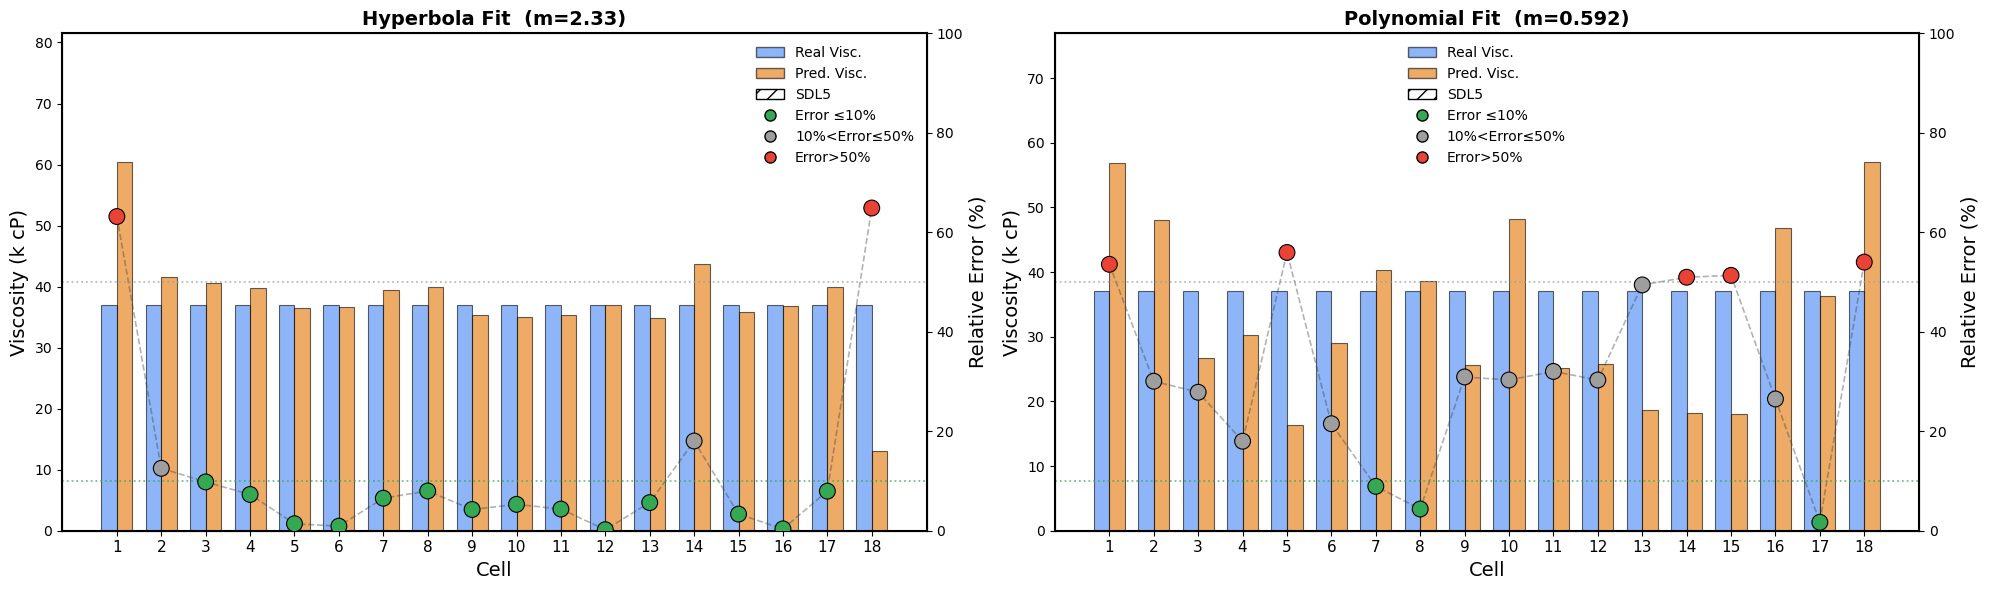

Learned scaling factors: {'poly': 0.592, 'hyperbola': 2.33}


In [7]:
pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=True,
)

print('Learned scaling factors:', pipeline_out['scales'])

In [8]:
pred_cols = [
    'cell',
    'a_poly2',
    'a_hyperbola',
    'real_viscosity',
    'predicted_visc_pol',
    'predicted_visc_hyp',
    'rel_error_pol',
    'rel_error_hyp',
    'is_calibration',
]

pred_df = pipeline_out['predictions'][pred_cols].sort_values('cell').reset_index(drop=True)
display(pred_df)

# Optional: save the predictions table
# pred_df.to_csv('viscosity_predictions_dynamic_analysis_L60kcP.csv', index=False)

,cell,a_poly2,a_hyperbola,real_viscosity,predicted_visc_pol,predicted_visc_hyp,rel_error_pol,rel_error_hyp,is_calibration
0,1,95.977704,25.910416,37000,56.818801,60.371270,53.564326,63.165594,True
1,2,81.284083,17.872246,37000,48.120177,41.642333,30.054532,12.546847,True
2,3,45.099157,17.438128,37000,26.698701,40.630838,27.841349,9.813074,True
3,4,51.251600,17.037502,37000,30.340947,39.697380,17.997440,7.290217,True
4,5,27.534948,15.656844,37000,16.300689,36.480446,55.944083,1.404201,True
5,6,49.056737,15.735031,37000,29.041588,36.662623,21.509221,0.911830,True
6,7,68.076127,16.917813,37000,40.301067,39.418504,8.921803,6.536498,True
7,8,65.228043,17.149056,37000,38.615002,39.957301,4.364869,7.992706,True
8,9,43.177967,15.202671,37000,25.561356,35.422224,30.915253,4.264259,True
9,10,81.440208,15.037657,37000,48.212603,35.037742,30.304332,5.303401,True
